<a href="https://colab.research.google.com/github/palahb/no2-prediction/blob/main/progress_report_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spatiotemporal NO2 Prediction using A3T-GCN
## Progress Report 2 - Model Training and Evaluation

**Course:** CMP712 - Machine Learning  
**Student:** Halil Burak Pala  
**Institution:** Hacettepe University, Department of Computer Engineering

---

This notebook trains four models on the preprocessed sliding window data from PR1.
It auto-resumes from the latest checkpoint on Drive if a disconnection occurred,
so you never lose training progress.

**Model architectures (from paper Table 4):**
- GRU     : FC(432, 512) -> GRU(512) -> FC(512, 24). Input = one time step flattened.
- LSTM    : FC(432, 512) -> LSTM(512) -> FC(512, 24).
- T-GCN   : GCN + GRU, hidden = 256. Input = (N, F) per time step, graph structure used.
- A3T-GCN : Same as T-GCN + soft attention over the 12-step window, hidden = 256.

## 1. Setup

In [ ]:
import torch
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.version.cuda}')
print(f'GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')

PyTorch : 2.10.0+cu128
CUDA    : 12.8
GPU     : Tesla T4


In [ ]:
!pip install torch-geometric -q
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv \
    -f https://data.pyg.org/whl/torch-2.10.0+cu128.html -q
!pip install torch-geometric-temporal -q
print('Done.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 110.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 37.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 98.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 9.2 MB/s eta 0:00:00
Done.


In [ ]:
import os, time, pickle, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch_geometric_temporal.nn.recurrent import A3TGCN, TGCN
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

Device : cuda


## 2. Paths and Auto-Resume Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PROJECT_ROOT = '/content/drive/MyDrive/cmp712_2026_project'
PREPROC_DIR  = f'{PROJECT_ROOT}/processed_data'
CKPT_DIR     = f'{PROJECT_ROOT}/checkpoints'
RESULTS_DIR  = f'{PROJECT_ROOT}/results'

os.makedirs(CKPT_DIR,    exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

def find_latest_checkpoint(model_name):
    """
    Scans the checkpoint folder and returns the path to the most
    recent epoch checkpoint for a given model. Returns None if none found.
    This is called automatically at the start of training so you never
    have to manually set resume paths after a disconnection.
    """
    pattern = os.path.join(CKPT_DIR, f'{model_name}_ep*.pt')
    files   = sorted(glob.glob(pattern))
    if files:
        latest = files[-1]
        print(f'  Found checkpoint: {os.path.basename(latest)}')
        return latest
    return None

print(f'Project root : {PROJECT_ROOT}')
print(f'Checkpoints  : {CKPT_DIR}')
print(f'Results      : {RESULTS_DIR}')

Project root : /content/drive/MyDrive/cmp712_2026_project
Checkpoints  : /content/drive/MyDrive/cmp712_2026_project/checkpoints
Results      : /content/drive/MyDrive/cmp712_2026_project/results


## 3. Load Preprocessed Data

We load the sliding window arrays saved in PR1.
Each sample is a 12-hour window of all 24 stations predicting 1 hour ahead.

Shapes:
- X_train: (4332, 24, 18, 12) - samples, stations, features, time steps
- y_train: (4332, 24)         - NO2 target at each of the 24 stations

In [ ]:
X_train = np.load(f'{PREPROC_DIR}/X_train.npy')
y_train = np.load(f'{PREPROC_DIR}/y_train.npy')
X_test  = np.load(f'{PREPROC_DIR}/X_test.npy')
y_test  = np.load(f'{PREPROC_DIR}/y_test.npy')

graph   = torch.load(f'{PREPROC_DIR}/graph_data.pt')
edge_index  = graph['edge_index'].to(device)
edge_weight = graph['edge_weight'].to(device)

with open(f'{PREPROC_DIR}/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

N_STATIONS  = 24
N_FEATURES  = 18
WINDOW      = 12
NUMERIC_COLS = ['NO2','windSpeed','Temp','Humidity','Pressure','SolarRad',
                'intensidad','ocupacion','carga','vmed']
NO2_MEAN = scaler.mean_[0]
NO2_STD  = scaler.scale_[0]

print(f'X_train : {X_train.shape}   (samples, stations, features, window)')
print(f'y_train : {y_train.shape}   (samples, stations)')
print(f'X_test  : {X_test.shape}')
print(f'y_test  : {y_test.shape}')
print(f'NO2 scaler -> mean={NO2_MEAN:.4f}, std={NO2_STD:.4f}')

X_train : (4332, 24, 18, 12)   (samples, stations, features, window)
y_train : (4332, 24)   (samples, stations)
X_test  : (4331, 24, 18, 12)
y_test  : (4331, 24)
NO2 scaler -> mean=36.6256, std=30.8578


## 4. DataLoaders

GRU and LSTM receive the window reshaped as a proper sequence:
  (batch, 12 time steps, 432 features) so the recurrent layer unrolls over time.

T-GCN and A3T-GCN receive the full (N, F, W) window and use the graph structure.

In [ ]:
BATCH_SIZE = 64

# RNN shape: (samples, window=12, N*F=432)
def to_rnn(X):
    S, N, F, W = X.shape
    return X.transpose(0, 3, 1, 2).reshape(S, W, N * F)

# Move ALL tensors to GPU once - this is the key speed fix.
# With batch_size=1 we cannot afford CPU->GPU transfer per sample.
X_train_rnn = torch.tensor(to_rnn(X_train), dtype=torch.float32).to(device)
X_test_rnn  = torch.tensor(to_rnn(X_test),  dtype=torch.float32).to(device)
y_train_t   = torch.tensor(y_train, dtype=torch.float32).to(device)
y_test_t    = torch.tensor(y_test,  dtype=torch.float32).to(device)

# Graph models: keep (S, N, F, W) on GPU
X_train_g = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_g  = torch.tensor(X_test,  dtype=torch.float32).to(device)

# RNN models still use DataLoader (they work fine with batched data)
rnn_train_loader = DataLoader(TensorDataset(X_train_rnn, y_train_t),
                              batch_size=BATCH_SIZE, shuffle=True)
rnn_test_loader  = DataLoader(TensorDataset(X_test_rnn,  y_test_t),
                              batch_size=BATCH_SIZE, shuffle=False)

# Graph models will iterate directly over indices - no DataLoader,
# no CPU/GPU transfers, no batching overhead.

print(f'All tensors moved to {device}')
print(f'X_train_rnn : {X_train_rnn.shape}   (samples, window=12, features=432)')
print(f'X_train_g   : {X_train_g.shape}  (samples, stations=24, features=18, window=12)')
print(f'RNN train batches : {len(rnn_train_loader)}')
print(f'Graph training: direct sample iteration, no DataLoader')

All tensors moved to cuda
X_train_rnn : torch.Size([4332, 12, 432])   (samples, window=12, features=432)
X_train_g   : torch.Size([4332, 24, 18, 12])  (samples, stations=24, features=18, window=12)
RNN train batches : 68
Graph training: direct sample iteration, no DataLoader


## 5. Model Definitions

In [ ]:
class GRUModel(nn.Module):
    """FC(432, 512) -> GRU(512) -> FC(512, 24). Input: (B, 12, 432)."""
    def __init__(self, input_size=432, hidden=512, n_out=24):
        super().__init__()
        self.fc_in  = nn.Linear(input_size, hidden)
        self.gru    = nn.GRU(hidden, hidden, batch_first=True)
        self.fc_out = nn.Linear(hidden, n_out)

    def forward(self, x):
        x = torch.relu(self.fc_in(x))
        out, _ = self.gru(x)
        return self.fc_out(out[:, -1])


class LSTMModel(nn.Module):
    """FC(432, 512) -> LSTM(512) -> FC(512, 24). Input: (B, 12, 432)."""
    def __init__(self, input_size=432, hidden=512, n_out=24):
        super().__init__()
        self.fc_in  = nn.Linear(input_size, hidden)
        self.lstm   = nn.LSTM(hidden, hidden, batch_first=True)
        self.fc_out = nn.Linear(hidden, n_out)

    def forward(self, x):
        x = torch.relu(self.fc_in(x))
        out, _ = self.lstm(x)
        return self.fc_out(out[:, -1])


class TGCNModel(nn.Module):
    """
    GCN + GRU, hidden = 256. Processes one sample at a time.
    Input: (N, F, W) - already on GPU, no transfers needed.
    """
    def __init__(self, in_channels=18, hidden=256):
        super().__init__()
        self.tgcn   = TGCN(in_channels=in_channels, out_channels=hidden)
        self.fc_out = nn.Linear(hidden, 1)

    def forward(self, x, edge_index, edge_weight):
        # x: (N, F, W) - one sample
        h = None
        for t in range(x.shape[-1]):
            h = self.tgcn(x[:, :, t], edge_index, edge_weight)
        return self.fc_out(h).squeeze(-1)  # (N,)


class A3TGCNModel(nn.Module):
    """
    GCN + GRU + attention, hidden = 256.
    Input: (N, F, W) - already on GPU.
    """
    def __init__(self, in_channels=18, hidden=256, periods=12):
        super().__init__()
        self.a3tgcn = A3TGCN(in_channels=in_channels,
                              out_channels=hidden,
                              periods=periods)
        self.fc_out = nn.Linear(hidden, 1)

    def forward(self, x, edge_index, edge_weight):
        # x: (N, F, W) - one sample
        h = self.a3tgcn(x, edge_index, edge_weight)
        return self.fc_out(h).squeeze(-1)  # (N,)


gru_model    = GRUModel().to(device)
lstm_model   = LSTMModel().to(device)
tgcn_model   = TGCNModel().to(device)
a3tgcn_model = A3TGCNModel().to(device)

for name, m in [('GRU', gru_model), ('LSTM', lstm_model),
                ('T-GCN', tgcn_model), ('A3T-GCN', a3tgcn_model)]:
    n = sum(p.numel() for p in m.parameters())
    print(f'{name:<10} : {n:,} parameters')

GRU        : 1,809,944 parameters
LSTM       : 2,335,256 parameters
T-GCN      : 408,833 parameters
A3T-GCN    : 408,845 parameters


## 6. Utilities

In [ ]:
def inverse_transform(arr):
    return arr * NO2_STD + NO2_MEAN


def compute_metrics(preds_norm, targets_norm):
    p = inverse_transform(np.array(preds_norm).flatten())
    t = inverse_transform(np.array(targets_norm).flatten())
    return {
        'RMSE': float(np.sqrt(mean_squared_error(t, p))),
        'MAE':  float(mean_absolute_error(t, p)),
        'R':    float(pearsonr(t, p)[0])
    }


def save_checkpoint(path, epoch, model, optimizer, scheduler,
                    train_losses, test_losses, best_loss, best_preds, best_targets):
    torch.save({
        'epoch':         epoch,
        'model':         model.state_dict(),
        'optimizer':     optimizer.state_dict(),
        'scheduler':     scheduler.state_dict(),
        'train_losses':  train_losses,
        'test_losses':   test_losses,
        'best_loss':     best_loss,
        'best_preds':    best_preds,
        'best_targets':  best_targets,
    }, path)


def load_checkpoint(path, model, optimizer, scheduler):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    print(f'  Resumed from epoch {ckpt["epoch"]} '
          f'(best test loss so far: {ckpt["best_loss"]:.5f})')
    return (ckpt['epoch'] + 1, ckpt['train_losses'], ckpt['test_losses'],
            ckpt['best_loss'], ckpt['best_preds'], ckpt['best_targets'])


print('Utilities ready.')

Utilities ready.


## 7. Training Loop

One function handles all four models.
- Auto-resumes from the latest checkpoint if Colab disconnected
- Saves a checkpoint every CKPT_EVERY epochs
- Early stopping if no improvement for PATIENCE epochs
- ReduceLROnPlateau halves the lr when validation loss stagnates

In [ ]:
def train_rnn_model(model, train_loader, test_loader, model_name,
                    n_epochs=100, lr=0.001, ckpt_every=5, patience=15):
    """Standard batched training for GRU and LSTM."""
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=7)

    resume_path = find_latest_checkpoint(model_name)

    start_epoch  = 1
    train_losses = []
    test_losses  = []
    best_loss    = float('inf')
    best_preds   = None
    best_targets = None
    no_improve   = 0

    if resume_path:
        start_epoch, train_losses, test_losses, best_loss, best_preds, best_targets = \
            load_checkpoint(resume_path, model, optimizer, scheduler)

    t0 = time.time()
    for epoch in range(start_epoch, n_epochs + 1):
        model.train()
        ep_train = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            ep_train += loss.item()
        ep_train /= len(train_loader)
        train_losses.append(ep_train)

        model.eval()
        ep_test = 0.0
        preds_list, targs_list = [], []
        with torch.no_grad():
            for xb, yb in test_loader:
                pred = model(xb)
                ep_test += criterion(pred, yb).item()
                preds_list.append(pred.cpu().numpy())
                targs_list.append(yb.cpu().numpy())
        ep_test /= len(test_loader)
        test_losses.append(ep_test)
        scheduler.step(ep_test)

        if ep_test < best_loss:
            best_loss    = ep_test
            best_preds   = np.concatenate(preds_list)
            best_targets = np.concatenate(targs_list)
            no_improve   = 0
            torch.save(model.state_dict(), f'{CKPT_DIR}/{model_name}_best.pt')
        else:
            no_improve += 1

        if epoch % ckpt_every == 0:
            ckpt_path = f'{CKPT_DIR}/{model_name}_ep{epoch:03d}.pt'
            save_checkpoint(ckpt_path, epoch, model, optimizer, scheduler,
                            train_losses, test_losses,
                            best_loss, best_preds, best_targets)
            print(f'  Checkpoint saved -> ep{epoch:03d}.pt')

        if epoch % 5 == 0 or epoch == 1:
            lr_now = optimizer.param_groups[0]['lr']
            print(f'[{model_name}] Ep {epoch:3d}/{n_epochs} | '
                  f'Train: {ep_train:.5f} | Test: {ep_test:.5f} | '
                  f'LR: {lr_now:.2e} | No-improve: {no_improve}/{patience} | '
                  f'Elapsed: {time.time()-t0:.0f}s')

        if no_improve >= patience:
            print(f'[{model_name}] Early stopping at epoch {epoch}.')
            break

    model.load_state_dict(
        torch.load(f'{CKPT_DIR}/{model_name}_best.pt', map_location=device))
    print(f'[{model_name}] Done. Best test MSE: {best_loss:.5f}')
    return train_losses, test_losses, best_preds, best_targets


def train_graph_model(model, X_train, y_train, X_test, y_test,
                      edge_index, edge_weight, model_name,
                      n_epochs=100, lr=0.001, ckpt_every=5, patience=15):
    """
    Direct sample iteration on GPU - no DataLoader, no CPU transfers.
    All tensors are already on GPU. We just iterate indices.
    """
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=7)

    resume_path = find_latest_checkpoint(model_name)

    start_epoch  = 1
    train_losses = []
    test_losses  = []
    best_loss    = float('inf')
    best_preds   = None
    best_targets = None
    no_improve   = 0

    if resume_path:
        start_epoch, train_losses, test_losses, best_loss, best_preds, best_targets = \
            load_checkpoint(resume_path, model, optimizer, scheduler)

    n_train = X_train.shape[0]
    n_test  = X_test.shape[0]
    t0 = time.time()

    for epoch in range(start_epoch, n_epochs + 1):
        # Training - direct iteration over samples on GPU
        model.train()
        perm     = torch.randperm(n_train)
        ep_train = 0.0
        for idx in perm:
            optimizer.zero_grad()
            pred = model(X_train[idx], edge_index, edge_weight)  # (N,)
            loss = criterion(pred, y_train[idx])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            ep_train += loss.item()
        ep_train /= n_train
        train_losses.append(ep_train)

        # Evaluation
        model.eval()
        ep_test    = 0.0
        preds_list = []
        targs_list = []
        with torch.no_grad():
            for i in range(n_test):
                pred = model(X_test[i], edge_index, edge_weight)
                ep_test += criterion(pred, y_test[i]).item()
                preds_list.append(pred.cpu().numpy())
                targs_list.append(y_test[i].cpu().numpy())
        ep_test /= n_test
        test_losses.append(ep_test)
        scheduler.step(ep_test)

        if ep_test < best_loss:
            best_loss    = ep_test
            best_preds   = np.stack(preds_list)
            best_targets = np.stack(targs_list)
            no_improve   = 0
            torch.save(model.state_dict(), f'{CKPT_DIR}/{model_name}_best.pt')
        else:
            no_improve += 1

        if epoch % ckpt_every == 0:
            ckpt_path = f'{CKPT_DIR}/{model_name}_ep{epoch:03d}.pt'
            save_checkpoint(ckpt_path, epoch, model, optimizer, scheduler,
                            train_losses, test_losses,
                            best_loss, best_preds, best_targets)
            print(f'  Checkpoint saved -> ep{epoch:03d}.pt')

        if epoch % 1 == 0 or epoch == 1:
            lr_now = optimizer.param_groups[0]['lr']
            print(f'[{model_name}] Ep {epoch:3d}/{n_epochs} | '
                  f'Train: {ep_train:.5f} | Test: {ep_test:.5f} | '
                  f'LR: {lr_now:.2e} | No-improve: {no_improve}/{patience} | '
                  f'Elapsed: {time.time()-t0:.0f}s')

        if no_improve >= patience:
            print(f'[{model_name}] Early stopping at epoch {epoch}.')
            break

    model.load_state_dict(
        torch.load(f'{CKPT_DIR}/{model_name}_best.pt', map_location=device))
    print(f'[{model_name}] Done. Best test MSE: {best_loss:.5f}')
    return train_losses, test_losses, best_preds, best_targets


print('Training functions ready.')

Training functions ready.


## 8. Train All Models

lr=0.001 with Adam is used here. This is appropriate because we use batched
DataLoaders (batch_size=64) which produce large gradients per step.
The paper's lr=0.1 is for snapshot-by-snapshot training where each step
has tiny gradients. Using 0.1 with batched loaders causes explosion.

Gradient clipping (max_norm=1.0) is added for extra stability.

If Colab disconnects, just re-run from this cell - the auto-resume
will find your latest checkpoint automatically.

In [ ]:
N_EPOCHS   = 100
LR         = 0.001
CKPT_EVERY = 5
PATIENCE   = 15

print(f'lr={LR}, batch_size={BATCH_SIZE}, max_epochs={N_EPOCHS}, patience={PATIENCE}')
print('Auto-resume is ON: latest checkpoint will be loaded automatically if found.')

lr=0.001, batch_size=64, max_epochs=100, patience=15
Auto-resume is ON: latest checkpoint will be loaded automatically if found.


In [ ]:
print('Training GRU...')
gru_tr, gru_te, gru_preds, gru_targets = train_rnn_model(
    gru_model, rnn_train_loader, rnn_test_loader,
    model_name='GRU', n_epochs=N_EPOCHS, lr=LR,
    ckpt_every=CKPT_EVERY, patience=PATIENCE)

gru_metrics = compute_metrics(gru_preds, gru_targets)
print(f"GRU  ->  RMSE: {gru_metrics['RMSE']:.4f}  "
      f"MAE: {gru_metrics['MAE']:.4f}  R: {gru_metrics['R']:.4f}")

Training GRU...
[GRU] Ep   1/100 | Train: 0.17322 | Test: 0.47199 | LR: 1.00e-03 | No-improve: 0/15 | Elapsed: 1s
  Checkpoint saved -> ep005.pt
[GRU] Ep   5/100 | Train: 0.08397 | Test: 0.48489 | LR: 1.00e-03 | No-improve: 3/15 | Elapsed: 3s
  Checkpoint saved -> ep010.pt
[GRU] Ep  10/100 | Train: 0.04216 | Test: 0.53153 | LR: 5.00e-04 | No-improve: 8/15 | Elapsed: 5s
  Checkpoint saved -> ep015.pt
[GRU] Ep  15/100 | Train: 0.02118 | Test: 0.54072 | LR: 5.00e-04 | No-improve: 13/15 | Elapsed: 7s
[GRU] Early stopping at epoch 17.
[GRU] Done. Best test MSE: 0.46946
GRU  ->  RMSE: 21.1591  MAE: 15.1089  R: 0.5415


In [ ]:
print('Training LSTM...')
lstm_tr, lstm_te, lstm_preds, lstm_targets = train_rnn_model(
    lstm_model, rnn_train_loader, rnn_test_loader,
    model_name='LSTM', n_epochs=N_EPOCHS, lr=LR,
    ckpt_every=CKPT_EVERY, patience=PATIENCE)

lstm_metrics = compute_metrics(lstm_preds, lstm_targets)
print(f"LSTM ->  RMSE: {lstm_metrics['RMSE']:.4f}  "
      f"MAE: {lstm_metrics['MAE']:.4f}  R: {lstm_metrics['R']:.4f}")

Training LSTM...
[LSTM] Ep   1/100 | Train: 0.37957 | Test: 0.51701 | LR: 1.00e-03 | No-improve: 0/15 | Elapsed: 0s
  Checkpoint saved -> ep005.pt
[LSTM] Ep   5/100 | Train: 0.11058 | Test: 0.52944 | LR: 1.00e-03 | No-improve: 3/15 | Elapsed: 2s
  Checkpoint saved -> ep010.pt
[LSTM] Ep  10/100 | Train: 0.05288 | Test: 0.54444 | LR: 5.00e-04 | No-improve: 8/15 | Elapsed: 5s
  Checkpoint saved -> ep015.pt
[LSTM] Ep  15/100 | Train: 0.02744 | Test: 0.56231 | LR: 5.00e-04 | No-improve: 13/15 | Elapsed: 8s
[LSTM] Early stopping at epoch 17.
[LSTM] Done. Best test MSE: 0.48175
LSTM ->  RMSE: 21.4397  MAE: 15.2866  R: 0.5207


In [ ]:
print('Training T-GCN...')
tgcn_tr, tgcn_te, tgcn_preds, tgcn_targets = train_graph_model(
    tgcn_model, X_train_g, y_train_t, X_test_g, y_test_t,
    edge_index, edge_weight,
    model_name='T-GCN', n_epochs=N_EPOCHS, lr=LR,
    ckpt_every=CKPT_EVERY, patience=PATIENCE)

tgcn_metrics = compute_metrics(tgcn_preds, tgcn_targets)
print(f"T-GCN->  RMSE: {tgcn_metrics['RMSE']:.4f}  "
      f"MAE: {tgcn_metrics['MAE']:.4f}  R: {tgcn_metrics['R']:.4f}")

Training T-GCN...
[T-GCN] Ep   1/100 | Train: 0.83221 | Test: 0.51003 | LR: 1.00e-03 | No-improve: 0/15 | Elapsed: 403s
[T-GCN] Ep   2/100 | Train: 0.77646 | Test: 0.50628 | LR: 1.00e-03 | No-improve: 0/15 | Elapsed: 813s
[T-GCN] Ep   3/100 | Train: 0.75133 | Test: 0.49756 | LR: 1.00e-03 | No-improve: 0/15 | Elapsed: 1220s
[T-GCN] Ep   4/100 | Train: 0.73314 | Test: 0.48807 | LR: 1.00e-03 | No-improve: 0/15 | Elapsed: 1620s
  Checkpoint saved -> ep005.pt
[T-GCN] Ep   5/100 | Train: 0.72112 | Test: 0.50274 | LR: 1.00e-03 | No-improve: 1/15 | Elapsed: 2024s
[T-GCN] Ep   6/100 | Train: 0.71280 | Test: 0.52102 | LR: 1.00e-03 | No-improve: 2/15 | Elapsed: 2429s
[T-GCN] Ep   7/100 | Train: 0.70272 | Test: 0.51531 | LR: 1.00e-03 | No-improve: 3/15 | Elapsed: 2833s
[T-GCN] Ep   8/100 | Train: 0.69525 | Test: 0.51084 | LR: 1.00e-03 | No-improve: 4/15 | Elapsed: 3237s
[T-GCN] Ep   9/100 | Train: 0.69023 | Test: 0.51142 | LR: 1.00e-03 | No-improve: 5/15 | Elapsed: 3640s
  Checkpoint saved -> ep01

In [ ]:
print('Training A3T-GCN...')
a3t_tr, a3t_te, a3t_preds, a3t_targets = train_graph_model(
    a3tgcn_model, X_train_g, y_train_t, X_test_g, y_test_t,
    edge_index, edge_weight,
    model_name='A3T-GCN', n_epochs=N_EPOCHS, lr=LR,
    ckpt_every=CKPT_EVERY, patience=PATIENCE)

a3t_metrics = compute_metrics(a3t_preds, a3t_targets)
print(f"A3T  ->  RMSE: {a3t_metrics['RMSE']:.4f}  "
      f"MAE: {a3t_metrics['MAE']:.4f}  R: {a3t_metrics['R']:.4f}")

Training A3T-GCN...
[A3T-GCN] Ep   1/100 | Train: 0.77405 | Test: 0.74808 | LR: 1.00e-03 | No-improve: 0/15 | Elapsed: 467s
[A3T-GCN] Ep   2/100 | Train: 0.70854 | Test: 0.64953 | LR: 1.00e-03 | No-improve: 0/15 | Elapsed: 935s
[A3T-GCN] Ep   3/100 | Train: 0.67562 | Test: 0.67901 | LR: 1.00e-03 | No-improve: 1/15 | Elapsed: 1408s
[A3T-GCN] Ep   4/100 | Train: 0.64610 | Test: 0.61016 | LR: 1.00e-03 | No-improve: 0/15 | Elapsed: 1883s
  Checkpoint saved -> ep005.pt
[A3T-GCN] Ep   5/100 | Train: 0.61705 | Test: 0.80476 | LR: 1.00e-03 | No-improve: 1/15 | Elapsed: 2358s
[A3T-GCN] Ep   6/100 | Train: 0.59125 | Test: 0.84838 | LR: 1.00e-03 | No-improve: 2/15 | Elapsed: 2834s
[A3T-GCN] Ep   7/100 | Train: 0.56571 | Test: 0.81986 | LR: 1.00e-03 | No-improve: 3/15 | Elapsed: 3308s
[A3T-GCN] Ep   8/100 | Train: 0.54282 | Test: 1.08493 | LR: 1.00e-03 | No-improve: 4/15 | Elapsed: 3782s
[A3T-GCN] Ep   9/100 | Train: 0.52259 | Test: 0.82376 | LR: 1.00e-03 | No-improve: 5/15 | Elapsed: 4253s
  Chec

## 9. Results

In [ ]:
PAPER = {
    'GRU':     {'RMSE': 22.29, 'MAE': 16.97, 'R': 0.56},
    'LSTM':    {'RMSE': 22.33, 'MAE': 16.70, 'R': 0.57},
    'T-GCN':   {'RMSE': 21.48, 'MAE': 16.24, 'R': 0.49},
    'A3T-GCN': {'RMSE': 19.14, 'MAE': 15.33, 'R': 0.59},
}
OUR = {
    'GRU':     gru_metrics,
    'LSTM':    lstm_metrics,
    'T-GCN':   tgcn_metrics,
    'A3T-GCN': a3t_metrics,
}

print('=' * 78)
print(f'{"Model":<12} {"RMSE":>8} {"Ref":>8} {"MAE":>8} {"Ref":>8} {"R":>8} {"Ref":>8}')
print('-' * 78)
for name in ['GRU', 'LSTM', 'T-GCN', 'A3T-GCN']:
    m, p = OUR[name], PAPER[name]
    print(f'{name:<12} {m["RMSE"]:>8.4f} {p["RMSE"]:>8.2f} '
          f'{m["MAE"]:>8.4f} {p["MAE"]:>8.2f} '
          f'{m["R"]:>8.4f} {p["R"]:>8.2f}')
print('=' * 78)
print('Reference: Iskandaryan et al. (2023), Table 5, horizon = 1-12h.')

rows = [{'Model': n,
         'RMSE_ours': OUR[n]['RMSE'], 'RMSE_paper': PAPER[n]['RMSE'],
         'MAE_ours':  OUR[n]['MAE'],  'MAE_paper':  PAPER[n]['MAE'],
         'R_ours':    OUR[n]['R'],    'R_paper':    PAPER[n]['R']}
        for n in ['GRU','LSTM','T-GCN','A3T-GCN']]
pd.DataFrame(rows).to_csv(f'{RESULTS_DIR}/metrics_summary.csv', index=False)
print(f'Saved to {RESULTS_DIR}/metrics_summary.csv')

Model            RMSE      Ref      MAE      Ref        R      Ref
------------------------------------------------------------------------------
GRU           21.1591    22.29  15.1089    16.97   0.5415     0.56
LSTM          21.4397    22.33  15.2866    16.70   0.5207     0.57
T-GCN         21.5577    21.48  15.9903    16.24   0.4129     0.49
A3T-GCN       24.1038    19.14  17.7651    15.33   0.4052     0.59
Reference: Iskandaryan et al. (2023), Table 5, horizon = 1-12h.
Saved to /content/drive/MyDrive/cmp712_2026_project/results/metrics_summary.csv


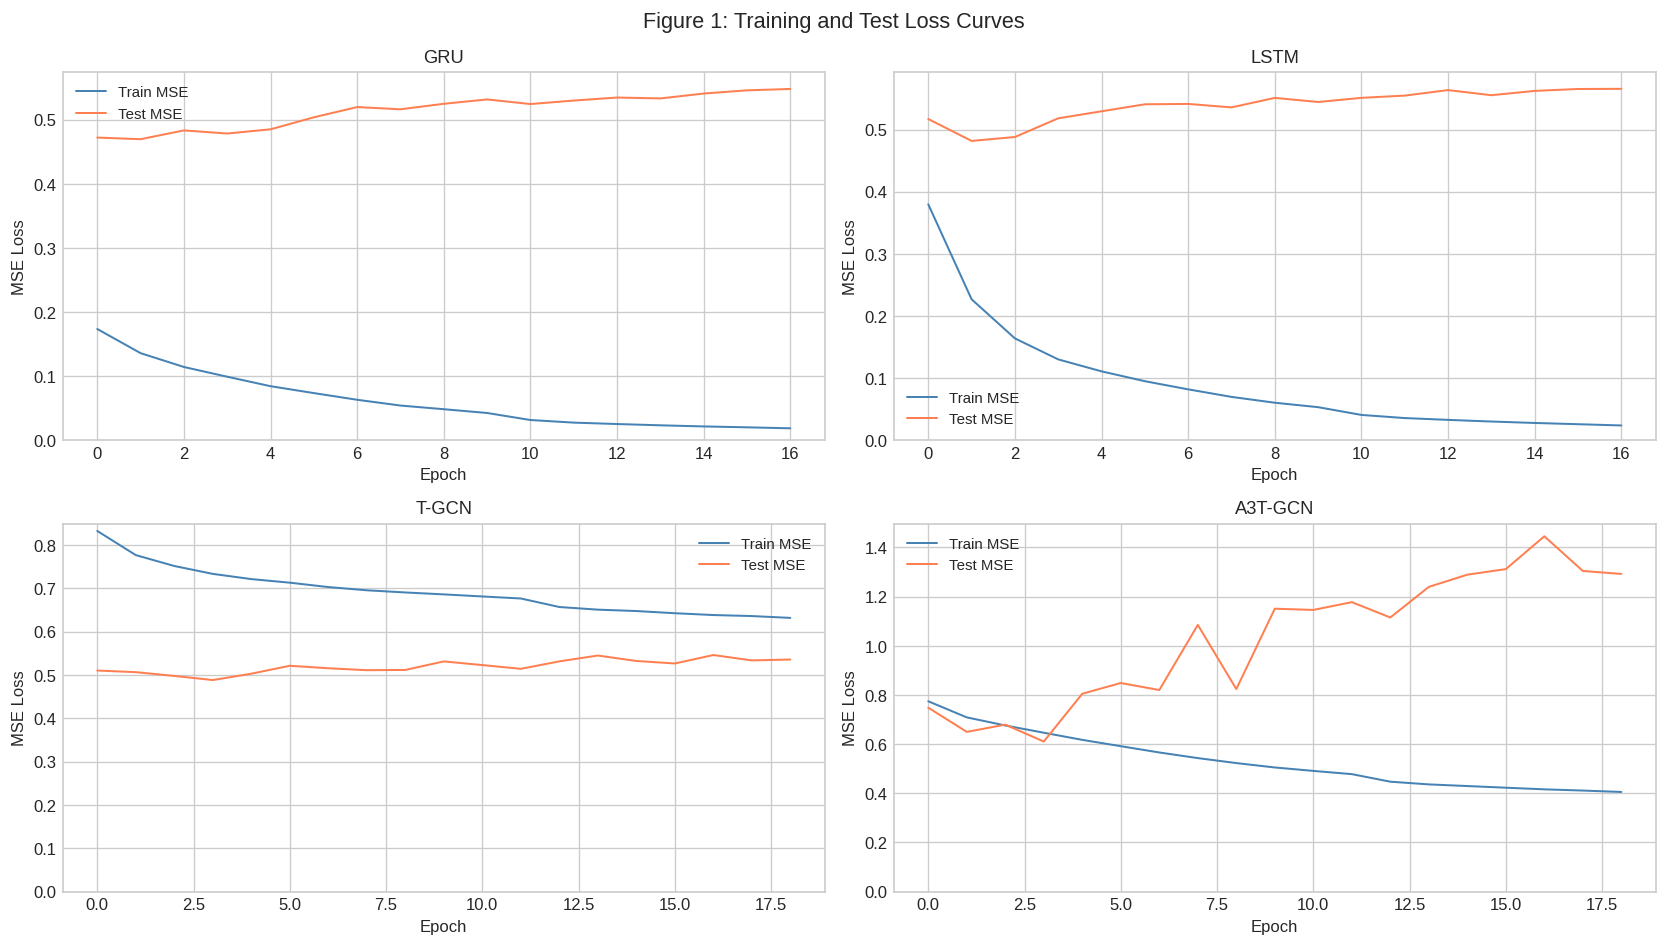

Saved fig1.


In [ ]:
# Loss curves for all four models
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for ax, (name, tr, te) in zip(axes, [
    ('GRU',     gru_tr,  gru_te),
    ('LSTM',    lstm_tr, lstm_te),
    ('T-GCN',   tgcn_tr, tgcn_te),
    ('A3T-GCN', a3t_tr,  a3t_te),
]):
    ax.plot(tr, label='Train MSE', color='steelblue', linewidth=1.2)
    ax.plot(te, label='Test MSE',  color='coral',     linewidth=1.2)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=9)
    ax.set_ylim(bottom=0)
plt.suptitle('Figure 1: Training and Test Loss Curves', fontsize=13)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig1_loss_curves.png', bbox_inches='tight')
plt.show()
print('Saved fig1.')

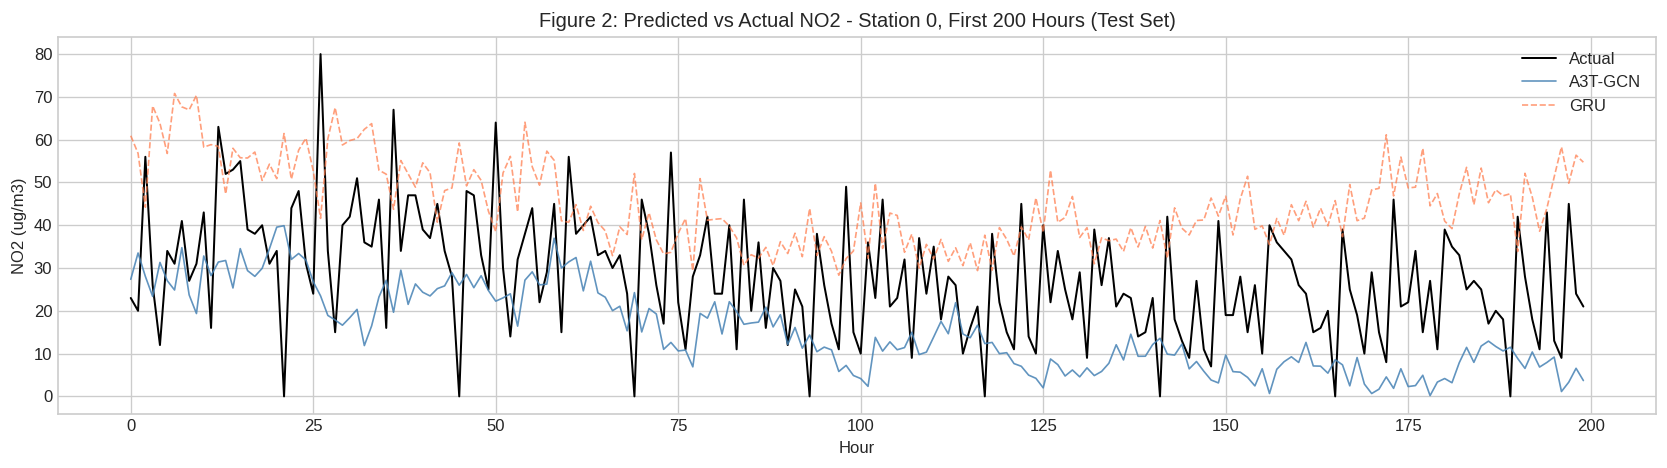

Saved fig2.


In [ ]:
# Prediction vs actual - station 0, first 200 hours
STATION = 0
N_HOURS = 200

actual   = inverse_transform(a3t_targets[:N_HOURS, STATION])
pred_a3t = inverse_transform(a3t_preds[:N_HOURS,   STATION])
pred_gru = inverse_transform(gru_preds[:N_HOURS,   STATION])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(actual,   label='Actual',  color='black',     linewidth=1.2)
ax.plot(pred_a3t, label='A3T-GCN', color='steelblue', linewidth=1.0, alpha=0.85)
ax.plot(pred_gru, label='GRU',     color='coral',     linewidth=1.0,
        alpha=0.75, linestyle='--')
ax.set_xlabel('Hour')
ax.set_ylabel('NO2 (ug/m3)')
ax.set_title(f'Figure 2: Predicted vs Actual NO2 - '
             f'Station {STATION}, First {N_HOURS} Hours (Test Set)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig2_predictions.png', bbox_inches='tight')
plt.show()
print('Saved fig2.')

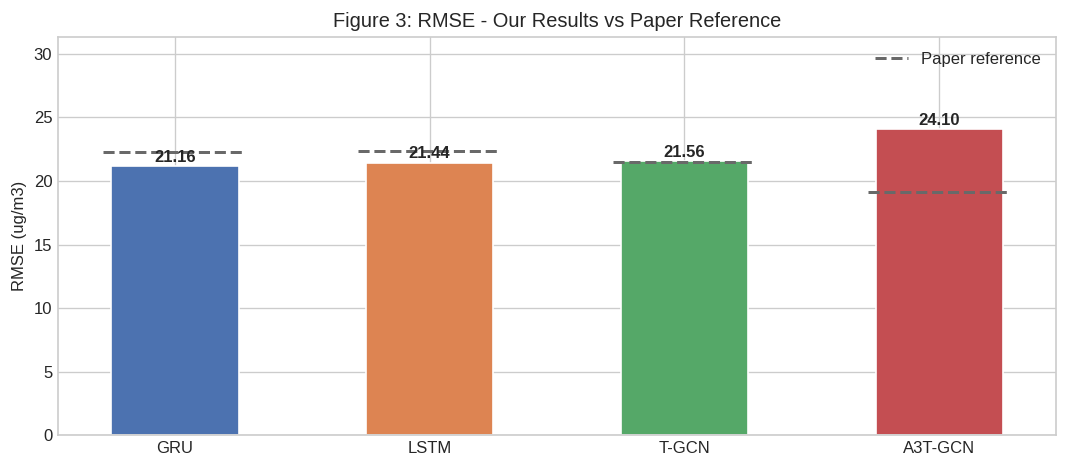

Saved fig3.


In [ ]:
# RMSE bar chart with paper reference lines
names      = ['GRU', 'LSTM', 'T-GCN', 'A3T-GCN']
rmse_ours  = [OUR[n]['RMSE']   for n in names]
rmse_paper = [PAPER[n]['RMSE'] for n in names]
colors     = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(names, rmse_ours, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, rmse_ours):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for i, pval in enumerate(rmse_paper):
    ax.hlines(pval, i - 0.28, i + 0.28, colors='dimgray',
              linestyles='--', linewidth=1.8,
              label='Paper reference' if i == 0 else '')
ax.set_ylabel('RMSE (ug/m3)')
ax.set_title('Figure 3: RMSE - Our Results vs Paper Reference')
ax.legend()
ax.set_ylim(0, max(rmse_ours) * 1.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig3_rmse_bar.png', bbox_inches='tight')
plt.show()
print('Saved fig3.')

In [ ]:
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
print('PROGRESS REPORT 2 - FINAL SUMMARY')
print(f'Platform  : Google Colab ({gpu_name})')
print(f'Optimizer : Adam, lr={LR}, gradient clipping max_norm=1.0')
print(f'Scheduler : ReduceLROnPlateau (factor=0.5, patience=7)')
print(f'Epochs    : max {N_EPOCHS}, early stop patience {PATIENCE}')
print()
print(f'{"Model":<12} {"RMSE":>8} {"Ref RMSE":>10} {"MAE":>8} {"Ref MAE":>9} {"R":>7} {"Ref R":>7}')
print('-' * 65)
for name in ['GRU', 'LSTM', 'T-GCN', 'A3T-GCN']:
    m, p = OUR[name], PAPER[name]
    print(f'{name:<12} {m["RMSE"]:>8.4f} {p["RMSE"]:>10.2f} '
          f'{m["MAE"]:>8.4f} {p["MAE"]:>9.2f} {m["R"]:>7.4f} {p["R"]:>7.2f}')

PROGRESS REPORT 2 - FINAL SUMMARY
Platform  : Google Colab (Tesla T4)
Optimizer : Adam, lr=0.001, gradient clipping max_norm=1.0
Scheduler : ReduceLROnPlateau (factor=0.5, patience=7)
Epochs    : max 100, early stop patience 15

Model            RMSE   Ref RMSE      MAE   Ref MAE       R   Ref R
-----------------------------------------------------------------
GRU           21.1591      22.29  15.1089     16.97  0.5415    0.56
LSTM          21.4397      22.33  15.2866     16.70  0.5207    0.57
T-GCN         21.5577      21.48  15.9903     16.24  0.4129    0.49
A3T-GCN       24.1038      19.14  17.7651     15.33  0.4052    0.59
